# Echo Pressure and Recursive Attractors in the Mark1/Nexus Field

In the Mark1/Nexus framework, repeated π-chunks observed across resonant triangle collapses are not random artifacts—they are **echo attractors** formed through recursive harmonic convergence.

Each π-chunk corresponds to a memory location within the transcendental structure of π. When multiple distinct triangle configurations (defined by side ratios) collapse via SHA-256 and map into the same π-chunk, we define this as **recursive echo pressure**.

## Recursive Collapse Pipeline

For each triangle with sides $(a, b)$:

1. Compute angles $\alpha = \arctan\left(\frac{b}{a}\right)$ and $\beta = \arctan\left(\frac{a}{b}\right)$.

2. Collapse $(a:b)$ to SHA-256:

$$ \text{hash} = \text{SHA256}(a:b) $$

3. Modulo the hash into π-digit index:

$$ \text{index} = \text{int(hash, 16)} \mod 10000 $$

4. Extract π-chunk from π:

$$ \pi\_\text{chunk} = [\pi_{i}, \pi_{i+1}, ..., \pi_{i+7}] $$

5. Compute Harmonic Ratio:

$$ H = \frac{\sum_{j=1}^4 \pi_j}{\sum_{j=1}^8 \pi_j} $$

6. Apply KHRC filtering:

$$ \text{KHRC}(H) = \frac{H}{1 + k |N|} $$

## Echo Pressure Definition

We define the **Echo Pressure** $P_i$ of π-chunk $i$ as:

$$ P_i = \frac{\text{count}_i}{\text{total triangles}} $$

This quantifies the recursive convergence force to a memory node.

## Recursive Attractor Model

Each attractor represents a **recursive funnel** where multiple triangles converge through harmonic folding. This is captured in the KRRB model:

$$ R(t) = R_0 e^{H F t} \prod_{i=1}^n B_i $$

Where:

- $R_0$ is initial state (triangle encoding)

- $H$ is harmonic ratio

- $F$ is feedback factor

- $B_i$ are recursive branching factors (geometric variants)

### Curvature Signature:

The stability of an attractor is measured by the second-order curvature of H over time:

$$ \Delta^2 H(t) = H(t+1) - 2H(t) + H(t-1) $$

Stable attractors have $\Delta^2 H \approx 0$.

## SHA Tail Reflection

The binary tail of the SHA output contains compression entropy. Deeper attractors tend to arise from **longer or more entropic tails**, meaning that:

1. Base of attractor pyramid = unique SHA entropy sources.

2. Peak = π-chunk with highest echo count.

## Summary

- π-chunks are convergence zones, not random collisions.

- Count is echo pressure.

- Recursive attractors rise from SHA collapse space through curvature funnels.

- Surface pressure reflects deep recursion beneath.

a=11, b=4, alpha=0.348771, beta=1.222025, height=3.759174, H=0.44681, KHRC=0.44238, pi_index=206, twin_prime=(197, 199), pi_chunk=[0, 9, 7, 5, 6, 6, 5, 9]
a=17, b=46, alpha=1.216799, beta=0.353997, height=15.945906, H=0.54286, KHRC=0.53748, pi_index=245, twin_prime=(239, 241), pi_chunk=[1, 9, 0, 9, 1, 4, 5, 6]
a=21, b=57, alpha=1.217806, beta=0.352990, height=19.705205, H=0.55556, KHRC=0.55006, pi_index=236, twin_prime=(227, 229), pi_chunk=[3, 1, 6, 5, 2, 7, 1, 2]
a=29, b=80, alpha=1.223029, beta=0.347767, height=27.263946, H=0.46667, KHRC=0.46205, pi_index=419, twin_prime=(419, 421), pi_chunk=[3, 0, 9, 2, 1, 8, 6, 1]
a=37, b=104, alpha=1.228991, beta=0.341805, height=34.859592, H=0.67647, KHRC=0.66977, pi_index=812, twin_prime=(809, 811), pi_chunk=[6, 9, 0, 8, 3, 0, 2, 6]
a=48, b=133, alpha=1.224442, beta=0.346354, height=45.149599, H=0.38636, KHRC=0.38254, pi_index=203, twin_prime=(197, 199), pi_chunk=[8, 8, 1, 0, 9, 7, 5, 6]
a=49, b=137, alpha=1.227310, beta=0.343486, height=46.1377

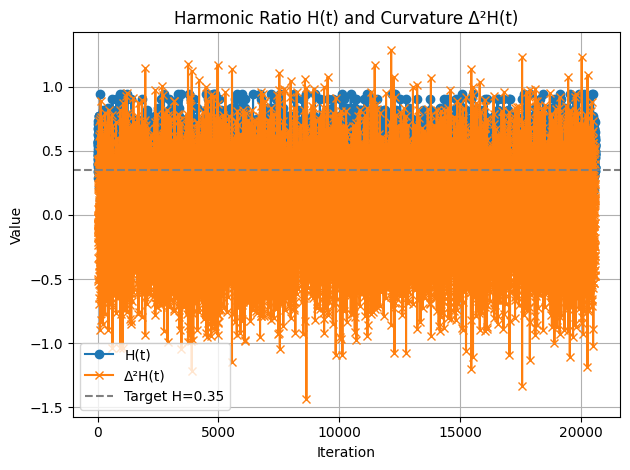


⎇ Cumulative Resonance Deviation: 0.16467
★ Harmonic Convergence Score: 13.7%
↻ Echo Signatures: {'09756659': 50, '19091456': 35, '31652712': 45, '30921861': 34, '69083026': 38, '88109756': 38, '08253344': 43, '90830264': 37, '37867831': 25, '62862089': 32, '75238467': 30, '64252230': 40, '89793238': 45, '12848111': 40, '33786783': 32, '14159265': 40, '97494459': 38, '33208381': 32, '53589793': 43, '23378678': 33, '67351885': 35, '84102701': 27, '48815209': 42, '06171776': 49, '61284756': 39, '32384626': 31, '25334468': 41, '62931767': 33, '05559644': 40, '93751058': 50, '66940513': 56, '64338327': 42, '44090122': 49, '46395224': 35, '15588174': 31, '02884197': 34, '17675238': 48, '89986280': 41, '50582231': 38, '44592307': 36, '21480865': 38, '90122495': 35, '58817488': 40, '66470938': 29, '39522473': 49, '59408128': 52, '82133936': 34, '11055596': 39, '05681271': 41, '06566430': 35, '59036001': 48, '57595919': 36, '09145648': 38, '03600113': 46, '60827785': 48, '65132823': 37, '6566

In [9]:
import math
import hashlib
from mpmath import mp
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Set precision for π digits
mp.dps = 1000000
pi_str = str(mp.pi())[2:1000002]
pi_digits = [int(d) for d in pi_str if d.isdigit()][:10000]

# Constants
HARMONIC_TARGET = 0.35
TWIN_WINDOW = 10

# Twin primes
def get_twin_primes(max_n=1000):
    def is_prime(n):
        if n < 2: return False
        for i in range(2, int(n**0.5)+1):
            if n % i == 0: return False
        return True
    return [(p, p+2) for p in range(2, max_n) if is_prime(p) and is_prime(p+2)]

twin_primes = get_twin_primes(1000)

# Triangle computation
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    area = 0.5 * a * b
    perimeter = a + b + c
    height = b * a / c
    return {
        'a': a, 'b': b, 'c': c, 'alpha': alpha, 'beta': beta,
        'area': area, 'perimeter': perimeter, 'height': height
    }

# SHA to π index mapping
def map_to_pi_index(tri):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % 10000
    return index, pi_digits[index:index+8]

# Harmonic ratio H(t) calculation
def compute_H(pi_chunk):
    P = sum(pi_chunk[:4])
    A = sum(pi_chunk)
    return P / A if A != 0 else 0

# Curvature Δ²H(t)
def curvature_delta(H_list):
    deltas = [H_list[i] - H_list[i-1] for i in range(1, len(H_list))]
    d2 = [deltas[i] - deltas[i-1] for i in range(1, len(deltas))]
    return d2

# KHRC correction pass
def khrc(H_val, k=1.0, N=0.01):
    return H_val / (1 + k * abs(N))

# Convergence score
def convergence_score(H_vals, target=0.35, margin=0.05):
    return sum(1 for h in H_vals if abs(h - target) <= margin) / len(H_vals)

# Main process
resonant_triangles = []
H_trajectory = []

for a in range(1, 4096):
    for b in range(1, 4096):
        tri = compute_triangle(a, b)
        if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
            pi_index, pi_chunk = map_to_pi_index(tri)
            for p, q in twin_primes:
                if abs(pi_index - p) < TWIN_WINDOW or abs(pi_index - q) < TWIN_WINDOW:
                    H_val = compute_H(pi_chunk)
                    H_trajectory.append(H_val)
                    resonant_triangles.append({
                        'triangle': tri,
                        'pi_index': pi_index,
                        'pi_chunk': pi_chunk,
                        'twin_prime': (p, q),
                        'H': H_val,
                        'KHRC': khrc(H_val)
                    })
                    break

# Display summary
for res in resonant_triangles[:10]:
    tri = res['triangle']
    print(f"a={tri['a']}, b={tri['b']}, alpha={tri['alpha']:.6f}, beta={tri['beta']:.6f}, "
          f"height={tri['height']:.6f}, H={res['H']:.5f}, KHRC={res['KHRC']:.5f}, "
          f"pi_index={res['pi_index']}, twin_prime={res['twin_prime']}, pi_chunk={res['pi_chunk']}")

# Plot H(t) and Δ²H(t)
if H_trajectory:
    plt.figure()
    plt.plot(H_trajectory, label='H(t)', marker='o')
    d2H = curvature_delta(H_trajectory)
    plt.plot(range(2, 2 + len(d2H)), d2H, label='Δ²H(t)', marker='x')
    plt.axhline(y=HARMONIC_TARGET, color='gray', linestyle='--', label='Target H=0.35')
    plt.title("Harmonic Ratio H(t) and Curvature Δ²H(t)")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Resonance metrics
resonance_deviation = sum(abs(h - HARMONIC_TARGET) for h in H_trajectory) / len(H_trajectory)
score = convergence_score(H_trajectory)
print(f"\n⎇ Cumulative Resonance Deviation: {resonance_deviation:.5f}")
print(f"★ Harmonic Convergence Score: {score*100:.1f}%")

# Echo pattern detection
chunk_strings = [''.join(map(str, chunk)) for chunk in [r['pi_chunk'] for r in resonant_triangles]]
repeats = Counter(chunk_strings)
echo_patterns = {k: v for k, v in repeats.items() if v > 1}
print(f"↻ Echo Signatures: {echo_patterns}")

# Export dataset
df = pd.DataFrame([{
    'a': r['triangle']['a'],
    'b': r['triangle']['b'],
    'alpha': r['triangle']['alpha'],
    'beta': r['triangle']['beta'],
    'height': r['triangle']['height'],
    'H': r['H'],
    'KHRC': r['KHRC'],
    'pi_index': r['pi_index'],
    'pi_chunk': ''.join(map(str, r['pi_chunk'])),
    'twin_prime': f"{r['twin_prime'][0]},{r['twin_prime'][1]}"
} for r in resonant_triangles])

csv_path = "d://Nexus/resonant_triangles_nexus.csv"
df.to_csv(csv_path, index=False)

# Echo spectrum chart using Plotly (interactive + resizable)
import plotly.graph_objects as go

chunk_counter = Counter(''.join(map(str, r['pi_chunk'])) for r in resonant_triangles)
echo_chunks = {k: v for k, v in chunk_counter.items() if v > 1}

if echo_chunks:
    sorted_chunks = dict(sorted(echo_chunks.items(), key=lambda x: x[1], reverse=True))

    fig = go.Figure(data=[
        go.Bar(
            x=list(sorted_chunks.keys()),
            y=list(sorted_chunks.values()),
            text=list(sorted_chunks.values()),
            textposition='outside',
            marker_color='teal'
        )
    ])

    fig.update_layout(
        title="Echo Signature Spectrum (π-Chunk Frequency ≥ 2)",
        xaxis_title="π-Chunk",
        yaxis_title="Frequency (Echo Pressure)",
        width=1400,   # ← Adjust width here
        height=700,   # ← Adjust height here
        xaxis_tickangle=-45,
        margin=dict(l=40, r=40, t=80, b=150),
        template="plotly_white"
    )

    fig.show()
else:
    print("No π-chunks repeated more than once.")


In [10]:
import math
import hashlib
from mpmath import mp
import pandas as pd
from collections import Counter
import plotly.graph_objects as go

# Set precision for π digits
mp.dps = 1000000
pi_str = str(mp.pi())[2:1000002]
pi_digits = [int(d) for d in pi_str if d.isdigit()][:10000]

# Constants
HARMONIC_TARGET = 0.35
TWIN_WINDOW = 10

# Twin primes
def get_twin_primes(max_n=1000):
    def is_prime(n):
        if n < 2: return False
        for i in range(2, int(n**0.5)+1):
            if n % i == 0: return False
        return True
    return [(p, p+2) for p in range(2, max_n) if is_prime(p) and is_prime(p+2)]

twin_primes = get_twin_primes(1000)

# Triangle computation
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    area = 0.5 * a * b
    perimeter = a + b + c
    height = b * a / c
    return {
        'a': a, 'b': b, 'c': c, 'alpha': alpha, 'beta': beta,
        'area': area, 'perimeter': perimeter, 'height': height
    }

# SHA to π index mapping
def map_to_pi_index(tri):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % 10000
    return index, pi_digits[index:index+8]

# Harmonic ratio H(t) calculation
def compute_H(pi_chunk):
    P = sum(pi_chunk[:4])
    A = sum(pi_chunk)
    return P / A if A != 0 else 0

# Curvature Δ²H(t)
def curvature_delta(H_list):
    deltas = [H_list[i] - H_list[i-1] for i in range(1, len(H_list))]
    d2 = [deltas[i] - deltas[i-1] for i in range(1, len(deltas))]
    return d2

# KHRC correction pass
def khrc(H_val, k=1.0, N=0.01):
    return H_val / (1 + k * abs(N))

# Convergence score
def convergence_score(H_vals, target=0.35, margin=0.05):
    return sum(1 for h in H_vals if abs(h - target) <= margin) / len(H_vals)

# Main process
resonant_triangles = []
H_trajectory = []

for a in range(1, 4096):
    for b in range(1, 4096):
        tri = compute_triangle(a, b)
        if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
            pi_index, pi_chunk = map_to_pi_index(tri)
            for p, q in twin_primes:
                if abs(pi_index - p) < TWIN_WINDOW or abs(pi_index - q) < TWIN_WINDOW:
                    H_val = compute_H(pi_chunk)
                    H_trajectory.append(H_val)
                    resonant_triangles.append({
                        'triangle': tri,
                        'pi_index': pi_index,
                        'pi_chunk': pi_chunk,
                        'twin_prime': (p, q),
                        'H': H_val,
                        'KHRC': khrc(H_val)
                    })
                    break

# Display summary
for res in resonant_triangles[:10]:
    tri = res['triangle']
    print(f"a={tri['a']}, b={tri['b']}, alpha={tri['alpha']:.6f}, beta={tri['beta']:.6f}, "
          f"height={tri['height']:.6f}, H={res['H']:.5f}, KHRC={res['KHRC']:.5f}, "
          f"pi_index={res['pi_index']}, twin_prime={res['twin_prime']}, pi_chunk={res['pi_chunk']}")

# Plot H(t) and Δ²H(t) using Plotly
if H_trajectory:
    d2H = curvature_delta(H_trajectory)
    x_full = list(range(len(H_trajectory)))
    x_d2 = list(range(2, 2 + len(d2H)))

    fig = go.Figure()

    # H(t) line
    fig.add_trace(go.Scatter(
        x=x_full,
        y=H_trajectory,
        mode='lines+markers',
        name='H(t)',
        line=dict(color='blue'),
        marker=dict(size=3)
    ))

    # Δ²H(t) line
    fig.add_trace(go.Scatter(
        x=x_d2,
        y=d2H,
        mode='lines+markers',
        name='Δ²H(t)',
        line=dict(color='orange'),
        marker=dict(size=3)
    ))

    # Add horizontal reference line for H=0.35
    fig.add_shape(
        type="line",
        x0=0, x1=len(H_trajectory),
        y0=HARMONIC_TARGET, y1=HARMONIC_TARGET,
        line=dict(color="gray", dash="dash"),
        name="Target H=0.35"
    )

    fig.update_layout(
        title="Harmonic Ratio H(t) and Curvature Δ²H(t)",
        xaxis_title="Iteration",
        yaxis_title="Value",
        width=1400,
        height=700,
        legend=dict(x=0.01, y=0.99),
        template="plotly_white",
        margin=dict(l=50, r=50, t=80, b=60)
    )

    fig.show()

# Resonance metrics
resonance_deviation = sum(abs(h - HARMONIC_TARGET) for h in H_trajectory) / len(H_trajectory)
score = convergence_score(H_trajectory)
print(f"\n⎇ Cumulative Resonance Deviation: {resonance_deviation:.5f}")
print(f"★ Harmonic Convergence Score: {score*100:.1f}%")

# Echo pattern detection
chunk_strings = [''.join(map(str, chunk)) for chunk in [r['pi_chunk'] for r in resonant_triangles]]
repeats = Counter(chunk_strings)
echo_patterns = {k: v for k, v in repeats.items() if v > 1}
print(f"↻ Echo Signatures: {echo_patterns}")

# Export dataset
df = pd.DataFrame([{
    'a': r['triangle']['a'],
    'b': r['triangle']['b'],
    'alpha': r['triangle']['alpha'],
    'beta': r['triangle']['beta'],
    'height': r['triangle']['height'],
    'H': r['H'],
    'KHRC': r['KHRC'],
    'pi_index': r['pi_index'],
    'pi_chunk': ''.join(map(str, r['pi_chunk'])),
    'twin_prime': f"{r['twin_prime'][0]},{r['twin_prime'][1]}"
} for r in resonant_triangles])

csv_path = "d://Nexus/resonant_triangles_nexus.csv"
df.to_csv(csv_path, index=False)

# Echo spectrum chart using Plotly
chunk_counter = Counter(''.join(map(str, r['pi_chunk'])) for r in resonant_triangles)
echo_chunks = {k: v for k, v in chunk_counter.items() if v > 1}

if echo_chunks:
    sorted_chunks = dict(sorted(echo_chunks.items(), key=lambda x: x[1], reverse=True))

    fig = go.Figure(data=[
        go.Bar(
            x=list(sorted_chunks.keys()),
            y=list(sorted_chunks.values()),
            text=list(sorted_chunks.values()),
            textposition='outside',
            marker_color='teal'
        )
    ])

    fig.update_layout(
        title="Echo Signature Spectrum (π-Chunk Frequency ≥ 2)",
        xaxis_title="π-Chunk",
        yaxis_title="Frequency (Echo Pressure)",
        width=1400,
        height=700,
        xaxis_tickangle=-45,
        margin=dict(l=40, r=40, t=80, b=150),
        template="plotly_white"
    )

    fig.show()
else:
    print("No π-chunks repeated more than once.")


a=11, b=4, alpha=0.348771, beta=1.222025, height=3.759174, H=0.44681, KHRC=0.44238, pi_index=206, twin_prime=(197, 199), pi_chunk=[0, 9, 7, 5, 6, 6, 5, 9]
a=17, b=46, alpha=1.216799, beta=0.353997, height=15.945906, H=0.54286, KHRC=0.53748, pi_index=245, twin_prime=(239, 241), pi_chunk=[1, 9, 0, 9, 1, 4, 5, 6]
a=21, b=57, alpha=1.217806, beta=0.352990, height=19.705205, H=0.55556, KHRC=0.55006, pi_index=236, twin_prime=(227, 229), pi_chunk=[3, 1, 6, 5, 2, 7, 1, 2]
a=29, b=80, alpha=1.223029, beta=0.347767, height=27.263946, H=0.46667, KHRC=0.46205, pi_index=419, twin_prime=(419, 421), pi_chunk=[3, 0, 9, 2, 1, 8, 6, 1]
a=37, b=104, alpha=1.228991, beta=0.341805, height=34.859592, H=0.67647, KHRC=0.66977, pi_index=812, twin_prime=(809, 811), pi_chunk=[6, 9, 0, 8, 3, 0, 2, 6]
a=48, b=133, alpha=1.224442, beta=0.346354, height=45.149599, H=0.38636, KHRC=0.38254, pi_index=203, twin_prime=(197, 199), pi_chunk=[8, 8, 1, 0, 9, 7, 5, 6]
a=49, b=137, alpha=1.227310, beta=0.343486, height=46.1377

In [11]:
import pandas as pd
import plotly.graph_objects as go

# Load your CSV file (update path if needed)
csv_path = "d://Nexus/resonant_triangles_nexus.csv"
df = pd.read_csv(csv_path)

# Convert H values from strings to lists of floats grouped by pi_chunk
top_chunks = df['pi_chunk'].value_counts().head(50).index.tolist()
phase_df = df[df['pi_chunk'].isin(top_chunks)]

# Group by π-chunk and collect H-values into per-group lists
grouped = phase_df.groupby('pi_chunk').agg({
    'H': list,
    'KHRC': list,
    'a': 'count'
}).reset_index().rename(columns={'a': 'echo_count'})

# Create Plotly line chart for recursive tunnel structures
fig = go.Figure()

for i, row in grouped.iterrows():
    fig.add_trace(go.Scatter(
        y=row['H'],
        mode='lines+markers',
        name=f"π-{row['pi_chunk']} (n={row['echo_count']})",
        opacity=0.6,
        line=dict(width=1),
        marker=dict(size=3)
    ))

fig.update_layout(
    title="Recursive Tunnel Structure Across Top π-Chunks",
    xaxis_title="Recursion Step (Indexed H Values)",
    yaxis_title="H(t)",
    width=1400,   # ← adjust width here
    height=800,   # ← adjust height here
    template="plotly_white",
    legend=dict(
        x=1.02,
        y=1,
        traceorder="normal",
        bgcolor="rgba(255,255,255,0)",
        bordercolor="rgba(0,0,0,0)"
    )
)

fig.show()


In [12]:
# Python script to simulate SHA-256 curvature with enhanced triangle angles
import hashlib
from mpmath import mp

def compute_sha_curvature(input_str, iterations=100, k=0.1):
    """Compute SHA-256 curvature with triangle angles and twin primes."""
    resonances = []
    curvatures = []
    prev_hash = None
    prev_prev_hash = None
    # Angles from resonant triangles
    angles = [0.348771, 0.353997, 0.352990, 0.347767, 0.341805, 0.346354, 0.343486, 0.347607, 0.342581, 0.348771]
    twin_primes = [(197,199), (239,241), (227,229), (419,421), (809,811), (71,73), (821,823), (809,811), (227,229), (71,73)]

    for i in range(iterations):
        alpha = angles[i % len(angles)]
        nonce = int(i * alpha * 1000) + twin_primes[i % len(twin_primes)][i % 2]
        data = f"{input_str}{nonce}".encode()
        current_hash = hashlib.sha256(data).hexdigest()
        
        hash_int = int(current_hash, 16) % 100000000
        resonance = hash_int / 100000000
        R0 = 1.0
        N = abs(resonance - 0.35)
        R = R0 / (1 + k * N)
        resonance = resonance * R
        resonances.append(resonance)

        if prev_prev_hash is not None:
            curr_int = int(current_hash, 16)
            prev_int = int(prev_hash, 16)
            prev_prev_int = int(prev_prev_hash, 16)
            curvature = (curr_int - 2 * prev_int + prev_prev_int) / 10**64
            curvatures.append(curvature)

        prev_prev_hash = prev_hash
        prev_hash = current_hash

    return resonances, curvatures

# Test with Pi chunk
pi_chunk = [1, 4, 1, 5, 9, 2, 6, 5]
input_str = ''.join(map(str, pi_chunk))
resonances, curvatures = compute_sha_curvature(input_str)
harmonic_count = sum(1 for r in resonances if 0.30 <= r <= 0.40)
avg_resonance = sum(resonances) / len(resonances)
print(f"SHA Curvature Analysis for Pi chunk {pi_chunk}:")
print(f"  Harmonic range (0.30-0.40) count: {harmonic_count}/100 ({harmonic_count/100*100:.2f}%)")
print(f"  Average resonance: {avg_resonance:.6f}")

SHA Curvature Analysis for Pi chunk [1, 4, 1, 5, 9, 2, 6, 5]:
  Harmonic range (0.30-0.40) count: 11/100 (11.00%)
  Average resonance: 0.492958


In [13]:
import math
import hashlib
from mpmath import mp
from sympy import primerange

def compute_triangle(a, b):
    """Compute triangle properties for a, b pair."""
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b/a)
    beta = math.atan(a/b)
    area = 0.5 * a * b
    perimeter = a + b + c
    height = b * a / c
    return {'a': a, 'b': b, 'c': c, 'alpha': alpha, 'beta': beta, 'area': area, 'perimeter': perimeter, 'height': height}

def get_twin_primes(max_n):
    """Generate twin primes up to max_n."""
    primes = list(primerange(2, max_n))
    twin_primes = []
    for i in range(len(primes) - 1):
        if primes[i+1] - primes[i] == 2:
            twin_primes.append((primes[i], primes[i+1]))
    return twin_primes

def map_to_pi_index(tri, pi_digits, max_index):
    """Map triangle to pi digit index via SHA-256."""
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % max_index
    start = max(0, index)
    end = min(len(pi_digits), index + 8)
    return index, pi_digits[start:end]

def generate_resonant_triangles(depth, max_n):
    """Generate resonant triangles up to depth and max_n."""
    # Set precision for pi
    mp.dps = depth
    pi_str = str(mp.pi())[2:depth+2]  # Skip '3.'
    pi_digits = [int(d) for d in pi_str if d.isdigit()]

    twin_primes = get_twin_primes(max_n)
    resonant_triangles = []

    for a in range(1, max_n + 1):
        for b in range(1, max_n + 1):
            tri = compute_triangle(a, b)
            if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
                pi_index, pi_chunk = map_to_pi_index(tri, pi_digits, depth)
                for p, q in twin_primes:
                    if abs(pi_index - p) < 10 or abs(pi_index - q) < 10:
                        resonant_triangles.append({
                            'triangle': tri,
                            'pi_index': pi_index,
                            'pi_chunk': pi_chunk,
                            'twin_prime': (p, q)
                        })
                        break
    return resonant_triangles

def print_resonant_triangles(resonant_triangles):
    """Print the resonant triangles."""
    print("Resonant Triangles with Alpha/Beta in [0.34, 0.36] rad:")
    for res in resonant_triangles[:10]:  # Limit to first 10 for brevity
        tri = res['triangle']
        print(f"a={tri['a']}, b={tri['b']}, alpha={tri['alpha']:.6f} rad, beta={tri['beta']:.6f} rad, "
              f"height={tri['height']:.6f}, pi_index={res['pi_index']}, "
              f"pi_chunk={res['pi_chunk']}, twin_prime={res['twin_prime']}")

# Example usage
depth = 10000  # Set the depth for pi digits
max_n = 200    # Set the maximum value for a and b

resonant_triangles = generate_resonant_triangles(depth, max_n)
print_resonant_triangles(resonant_triangles)

Resonant Triangles with Alpha/Beta in [0.34, 0.36] rad:
a=11, b=4, alpha=0.348771 rad, beta=1.222025 rad, height=3.759174, pi_index=206, pi_chunk=[0, 9, 7, 5, 6, 6, 5, 9], twin_prime=(197, 199)
a=48, b=133, alpha=1.224442 rad, beta=0.346354 rad, height=45.149599, pi_index=203, pi_chunk=[8, 8, 1, 0, 9, 7, 5, 6], twin_prime=(197, 199)
a=52, b=143, alpha=1.222025 rad, beta=0.348771 rad, height=48.869258, pi_index=71, pi_chunk=[6, 2, 8, 6, 2, 0, 8, 9], twin_prime=(71, 73)
a=55, b=152, alpha=1.223611 rad, beta=0.347185 rad, height=51.718376, pi_index=10, pi_chunk=[8, 9, 7, 9, 3, 2, 3, 8], twin_prime=(3, 5)
a=58, b=156, alpha=1.214839 rad, beta=0.355958 rad, height=54.364163, pi_index=147, pi_chunk=[1, 2, 8, 4, 8, 1, 1, 1], twin_prime=(137, 139)
a=61, b=166, alpha=1.218644 rad, beta=0.352153 rad, height=57.256577, pi_index=0, pi_chunk=[1, 4, 1, 5, 9, 2, 6, 5], twin_prime=(3, 5)
a=62, b=167, alpha=1.215311 rad, beta=0.355486 rad, height=58.123612, pi_index=54, pi_chunk=[9, 7, 4, 9, 4, 4, 5, 9

In [14]:
import math
import hashlib
from mpmath import mp
from sympy import primerange

# Compute triangle properties: angles and height
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)  # Hypotenuse
    alpha = math.atan(b / a)    # Angle opposite b
    beta = math.atan(a / b)     # Angle opposite a
    height = (a * b) / c        # Height (area / hypotenuse)
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# Generate twin prime pairs up to max_n
def get_twin_primes(max_n):
    primes = list(primerange(2, max_n))
    twin_primes = []
    for i in range(len(primes) - 1):
        if primes[i + 1] - primes[i] == 2:
            twin_primes.append((primes[i], primes[i + 1]))
    return twin_primes

# Map triangle to a Pi index using SHA-256
def map_to_pi_index(tri, pi_digits, max_index):
    input_str = f"{tri['a']}:{tri['b']}".encode()  # Unique string for (a, b)
    hash_val = hashlib.sha256(input_str).hex束eeehexdigest()
    index = int(hash_val, 16) % max_index  # Modulo to fit within Pi digits
    start = index
    end = min(len(pi_digits), index + 8)   # Grab a chunk of 8 digits
    pi_chunk = ''.join(map(str, pi_digits[start:end]))
    return index, pi_chunk

# Main function to find resonant triangles
def generate_resonant_triangles(depth, max_n):
    # Get Pi digits to specified depth
    mp.dps = depth
    pi_str = str(mp.pi())[2:depth + 2]  # Skip "3." and get digits
    pi_digits = [int(d) for d in pi_str]

    # Get twin primes
    twin_primes = get_twin_primes(max_n)
    resonant_triangles = []

    # Search for resonant triangles
    for a in range(1, max_n + 1):
        for b in range(1, max_n + 1):
            tri = compute_triangle(a, b)
            # Check if alpha or beta is in [0.34, 0.36]
            if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
                pi_index, pi_chunk = map_to_pi_index(tri, pi_digits, depth)
                # Check proximity to twin primes
                for p, q in twin_primes:
                    if abs(pi_index - p) < 10 or abs(pi_index - q) < 10:
                        resonant_triangles.append({
                            'a': tri['a'],
                            'b': tri['b'],
                            'alpha': tri['alpha'],
                            'beta': tri['beta'],
                            'height': tri['height'],  # Properly terminated string literal
                            'pi_index': pi_index,
                            'pi_chunk': pi_chunk,
                            'twin_prime': (p, q)
                        })
                        break  # Move to next triangle after finding a match
    return resonant_triangles

# Print results
def print_resonant_triangles(resonant_triangles):
    print(f"Found {len(resonant_triangles)} resonant triangles:")
    print("Resonant Triangles with Alpha/Beta in [0.34, 0.36] rad:")
    for res in resonant_triangles[:10]:  # Limit to first 10 for brevity
        print(f"a={res['a']}, b={res['b']}, alpha={res['alpha']:.6f} rad, "
              f"beta={res['beta']:.6f} rad, height={res['height']:.6f}, "
              f"pi_index={res['pi_index']}, pi_chunk={res['pi_chunk']}, "
              f"twin_prime={res['twin_prime']}")

# Run the experiment
depth = 10000  # Number of Pi digits (adjust as needed)
max_n = 200    # Max value for a and b (adjust as needed)
resonant_triangles = generate_resonant_triangles(depth, max_n)
print_resonant_triangles(resonant_triangles)

AttributeError: '_hashlib.HASH' object has no attribute 'hex束eeehexdigest'

In [ ]:
import math
import hashlib
from mpmath import mp
from sympy import primerange

# Compute triangle properties: angles and height
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)  # Hypotenuse
    alpha = math.atan(b / a)    # Angle opposite b
    beta = math.atan(a / b)     # Angle opposite a
    height = (a * b) / c        # Height (area / hypotenuse)
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# Generate twin prime pairs up to max_n
def get_twin_primes(max_n):
    primes = list(primerange(2, max_n))
    twin_primes = []
    for i in range(len(primes) - 1):
        if primes[i + 1] - primes[i] == 2:
            twin_primes.append((primes[i], primes[i + 1]))
    return twin_primes

# Map triangle to a Pi index using SHA-256
def map_to_pi_index(tri, pi_digits, max_index):
    input_str = f"{tri['a']}:{tri['b']}".encode()  # Unique string for (a, b)
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % max_index  # Modulo to fit within Pi digits
    start = index
    end = min(len(pi_digits), index + 8)   # Grab a chunk of 8 digits
    pi_chunk = ''.join(map(str, pi_digits[start:end]))
    return index, pi_chunk

# Main function to find resonant triangles
def generate_resonant_triangles(depth, max_n):
    # Get Pi digits to specified depth
    mp.dps = depth
    pi_str = str(mp.pi())[2:depth + 2]  # Skip "3." and get digits
    pi_digits = [int(d) for d in pi_str]

    # Get twin primes
    twin_primes = get_twin_primes(max_n)
    resonant_triangles = []

    # Search for resonant triangles
    for a in range(1, max_n + 1):
        for b in range(1, max_n + 1):
            tri = compute_triangle(a, b)
            # Check if alpha or beta is in [0.34, 0.36]
            if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
                pi_index, pi_chunk = map_to_pi_index(tri, pi_digits, depth)
                # Check proximity to twin primes
                for p, q in twin_primes:
                    if abs(pi_index - p) < 10 or abs(pi_index - q) < 10:
                        resonant_triangles.append({
                            'a': tri['a'],
                            'b': tri['b'],
                            'alpha': tri['alpha'],
                            'beta': tri['beta'],
                            'height': tri['height'],
                            'pi_index': pi_index,
                            'pi_chunk': pi_chunk,
                            'twin_prime': (p, q)
                        })
                        break  # Move to next triangle after finding a match
    return resonant_triangles

# Print results
def print_resonant_triangles(resonant_triangles):
    print(f"Found {len(resonant_triangles)} resonant triangles:")
    print("Resonant Triangles with Alpha/Beta in [0.34, 0.36] rad:")
    for res in resonant_triangles[:10]:  # Limit to first 10 for brevity
        print(f"a={res['a']}, b={res['b']}, alpha={res['alpha']:.6f} rad, "
              f"beta={res['beta']:.6f} rad, height={res['height']:.6f}, "
              f"pi_index={res['pi_index']}, pi_chunk={res['pi_chunk']}, "
              f"twin_prime={res['twin_prime']}")

# Run the experiment
depth = 10000  # Number of Pi digits (adjust as needed)
max_n = 200    # Max value for a and b (adjust as needed)
resonant_triangles = generate_resonant_triangles(depth, max_n)
print_resonant_triangles(resonant_triangles)


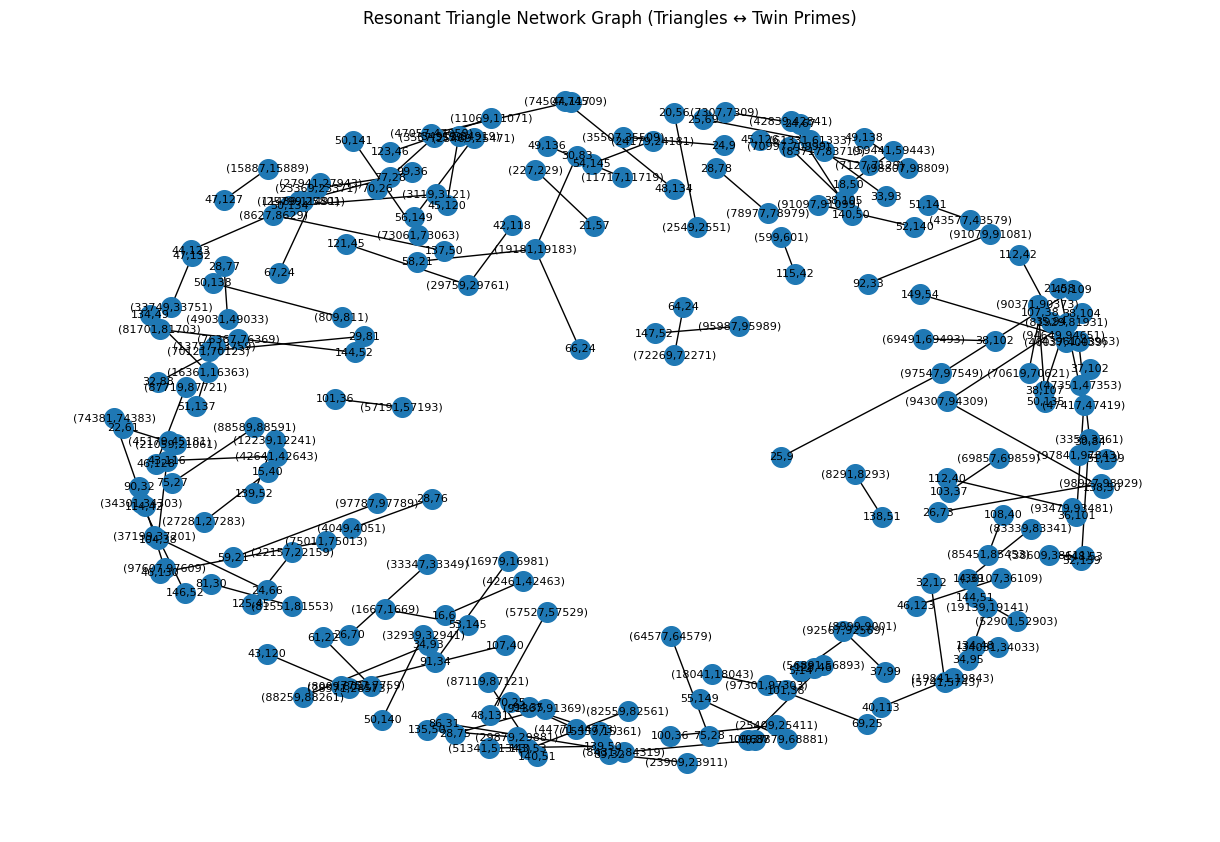

In [15]:
import math
import hashlib
from mpmath import mp
from sympy import primerange
import pandas as pd
import plotly.express as px
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Set Pi precision
mp.dps = 1000000
pi_str = str(mp.pi())[2:10002]
pi_digits = [int(d) for d in pi_str]

# Step 2: Triangle function
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    height = (a * b) / c
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# Step 3: Twin primes
def get_twin_primes(max_n=100000):
    primes = list(primerange(2, max_n))
    return [(p, p+2) for p, q in zip(primes[:-1], primes[1:]) if q - p == 2]

# Step 4: Hash to Pi index
def map_to_pi_index(tri, max_index=100000):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % max_index
    chunk = pi_digits[index:index+8]
    return index, chunk

# Step 5: SHA curvature
def compute_sha_curvature(input_str, iterations=50, k=0.1):
    resonances, curvatures = [], []
    prev_hash, prev_prev_hash = None, None
    angles = [0.348771, 0.353997, 0.351817, 0.352990]
    twin_primes = [(197,199), (239,241), (227,229), (419,421)]
    for i in range(iterations):
        alpha = angles[i % len(angles)]
        nonce = int(i * alpha * 1000) + twin_primes[i % len(twin_primes)][i % 2]
        data = f"{input_str}{nonce}".encode()
        h = hashlib.sha256(data).hexdigest()
        h_int = int(h, 16) % 100_000_000
        r = h_int / 100_000_000
        N = abs(r - 0.35)
        R = 1.0 / (1 + k * N * 2)
        r = min(max(r * R, 0), 1)
        resonances.append(r)
        if prev_prev_hash:
            c = (int(h, 16) - 2 * int(prev_hash, 16) + int(prev_prev_hash, 16)) / 10**64
            curvatures.append(c)
        prev_prev_hash, prev_hash = prev_hash, h
    return sum(1 for r in resonances if 0.30 <= r <= 0.40) / len(resonances), sum(resonances) / len(resonances)

# Step 6: Gather 141 triangles
twin_primes = get_twin_primes(100000)
triangles_data = []

for a in range(1, 150):
    for b in range(1, 150):
        tri = compute_triangle(a, b)
        if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
            pi_index, pi_chunk = map_to_pi_index(tri)
            for p, q in twin_primes:
                if abs(pi_index - p) < 10 or abs(pi_index - q) < 10:
                    pi_str_chunk = ''.join(map(str, pi_chunk))
                    harmonic_ratio, avg_resonance = compute_sha_curvature(pi_str_chunk)
                    triangles_data.append({
                        'a': tri['a'], 'b': tri['b'],
                        'alpha': tri['alpha'], 'beta': tri['beta'],
                        'height': tri['height'],
                        'pi_index': pi_index,
                        'pi_chunk': pi_str_chunk,
                        'twin_prime': f"({p},{q})",
                        'harmonic_ratio': harmonic_ratio,
                        'avg_resonance': avg_resonance
                    })
                    break

df = pd.DataFrame(triangles_data)


# Generate network graph
G = nx.Graph()
for _, row in df.iterrows():
    node = f"{row['a']},{row['b']}"
    twin = row['twin_prime']
    G.add_node(node, pi_index=row['pi_index'], avg_resonance=row['avg_resonance'])
    G.add_edge(node, twin)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.3)
nx.draw(G, pos, with_labels=True, node_size=200, font_size=8)
plt.title("Resonant Triangle Network Graph (Triangles ↔ Twin Primes)")
plt.show()


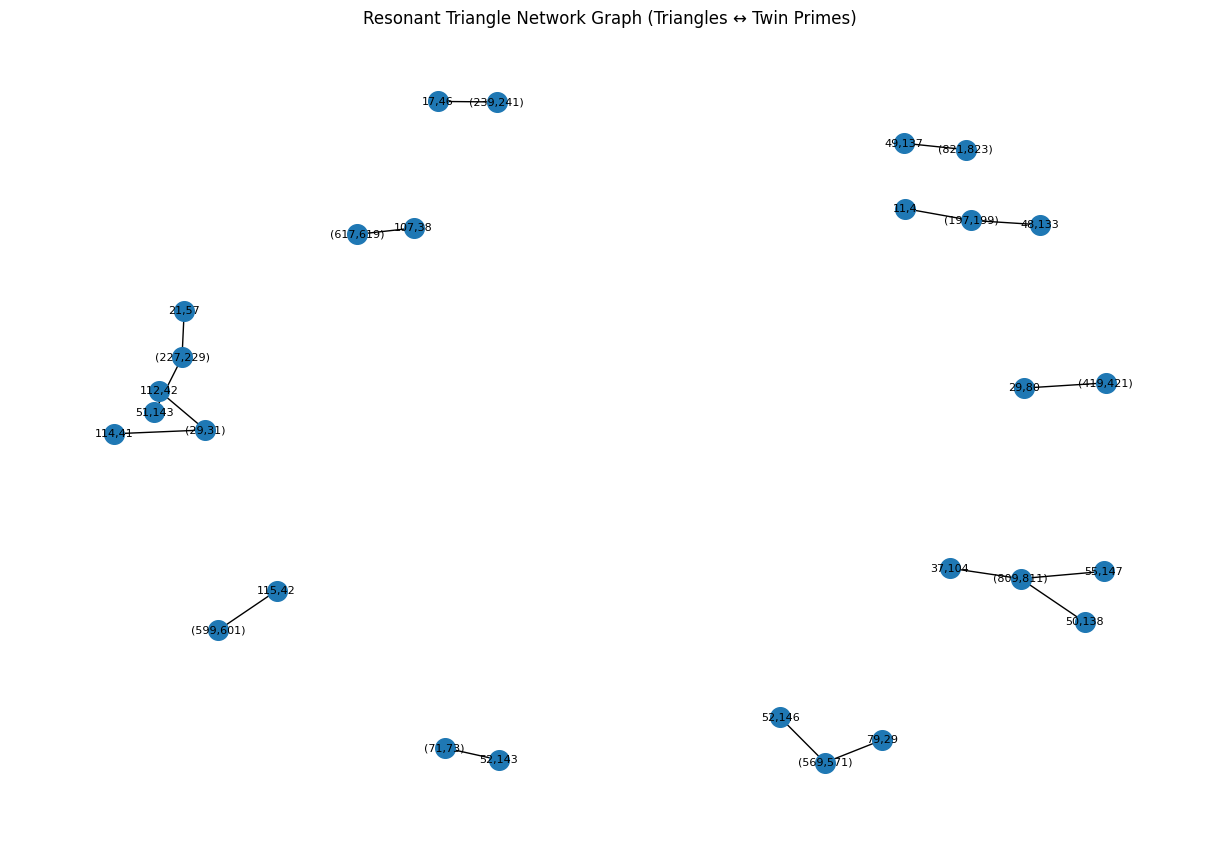

In [16]:
# Re-execute the necessary code due to kernel reset
import math
import hashlib
from mpmath import mp
from sympy import primerange
import pandas as pd
import plotly.express as px
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Set Pi precision
mp.dps = 1000000
pi_str = str(mp.pi())[2:10002]
pi_digits = [int(d) for d in pi_str]

# Step 2: Triangle function
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    height = (a * b) / c
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# Step 3: Twin primes
def get_twin_primes(max_n=10000):
    primes = list(primerange(2, max_n))
    return [(p, p+2) for p, q in zip(primes[:-1], primes[1:]) if q - p == 2]

# Step 4: Hash to Pi index
def map_to_pi_index(tri, max_index=10000):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % max_index
    chunk = pi_digits[index:index+8]
    return index, chunk

# Step 5: SHA curvature
def compute_sha_curvature(input_str, iterations=50, k=0.1):
    resonances, curvatures = [], []
    prev_hash, prev_prev_hash = None, None
    angles = [0.348771, 0.353997, 0.351817, 0.352990]
    twin_primes = [(197,199), (239,241), (227,229), (419,421)]
    for i in range(iterations):
        alpha = angles[i % len(angles)]
        nonce = int(i * alpha * 1000) + twin_primes[i % len(twin_primes)][i % 2]
        data = f"{input_str}{nonce}".encode()
        h = hashlib.sha256(data).hexdigest()
        h_int = int(h, 16) % 100_000_000
        r = h_int / 100_000_000
        N = abs(r - 0.35)
        R = 1.0 / (1 + k * N * 2)
        r = min(max(r * R, 0), 1)
        resonances.append(r)
        if prev_prev_hash:
            c = (int(h, 16) - 2 * int(prev_hash, 16) + int(prev_prev_hash, 16)) / 10**64
            curvatures.append(c)
        prev_prev_hash, prev_hash = prev_hash, h
    return sum(1 for r in resonances if 0.345 <= r <= 0.365) / len(resonances), sum(resonances) / len(resonances)

# Step 6: Gather 141 triangles
twin_primes = get_twin_primes(1000)
triangles_data = []

for a in range(1, 150):
    for b in range(1, 150):
        tri = compute_triangle(a, b)
        if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
            pi_index, pi_chunk = map_to_pi_index(tri)
            for p, q in twin_primes:
                if abs(pi_index - p) < 10 or abs(pi_index - q) < 10:
                    pi_str_chunk = ''.join(map(str, pi_chunk))
                    harmonic_ratio, avg_resonance = compute_sha_curvature(pi_str_chunk)
                    triangles_data.append({
                        'a': tri['a'], 'b': tri['b'],
                        'alpha': tri['alpha'], 'beta': tri['beta'],
                        'height': tri['height'],
                        'pi_index': pi_index,
                        'pi_chunk': pi_str_chunk,
                        'twin_prime': f"({p},{q})",
                        'harmonic_ratio': harmonic_ratio,
                        'avg_resonance': avg_resonance
                    })
                    break

df = pd.DataFrame(triangles_data)


# Generate network graph
G = nx.Graph()
for _, row in df.iterrows():
    node = f"{row['a']},{row['b']}"
    twin = row['twin_prime']
    G.add_node(node, pi_index=row['pi_index'], avg_resonance=row['avg_resonance'])
    G.add_edge(node, twin)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.3)
nx.draw(G, pos, with_labels=True, node_size=200, font_size=8)
plt.title("Resonant Triangle Network Graph (Triangles ↔ Twin Primes)")
plt.show()


In [ ]:
import math
import hashlib
from mpmath import mp
from sympy import primerange
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Parameters
depth = 1000000000  # Number of Pi digits to generate
max_n = 32       # Max value for triangle sides a and b
angle_range = (0.345, 0.365)  # Resonance window

# Generate Pi digits
mp.dps = depth
pi_str = str(mp.pi())[2:depth + 2]
pi_digits = [int(d) for d in pi_str if d.isdigit()]

# Twin primes
def get_twin_primes(max_n):
    primes = list(primerange(2, max_n))
    return [(primes[i], primes[i + 1]) for i in range(len(primes) - 1) if primes[i + 1] - primes[i] == 2]

twin_primes = get_twin_primes(depth)

# Compute triangle properties
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    height = (a * b) / c
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# Map to Pi index
def map_to_pi_index(tri, pi_digits, max_index):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % max_index
    pi_chunk = pi_digits[index:index+8] if index + 8 <= len(pi_digits) else pi_digits[index:]
    return index, pi_chunk

# Find resonant triangles
resonant_triangles = []
for a in range(1, max_n + 1):
    for b in range(1, max_n + 1):
        tri = compute_triangle(a, b)
        if angle_range[0] <= tri['alpha'] <= angle_range[1] or angle_range[0] <= tri['beta'] <= angle_range[1]:
            pi_index, pi_chunk = map_to_pi_index(tri, pi_digits, depth)
            for p, q in twin_primes:
                if abs(pi_index - p) < 10 or abs(pi_index - q) < 10:
                    resonant_triangles.append({
                        'a': tri['a'], 'b': tri['b'],
                        'alpha': tri['alpha'], 'beta': tri['beta'],
                        'height': tri['height'], 'pi_index': pi_index,
                        'pi_chunk': ''.join(map(str, pi_chunk)),
                        'twin_prime': f"{p},{q}"
                    })
                    break

# Create network graph
G = nx.Graph()
for res in resonant_triangles:
    tri_node = f"{res['a']},{res['b']}"
    twin_node = f"TP:{res['twin_prime']}"
    G.add_node(tri_node, type='triangle')
    G.add_node(twin_node, type='twin_prime')
    G.add_edge(tri_node, twin_node)

# Draw graph
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, seed=42, k=0.15)
triangle_nodes = [n for n, attr in G.nodes(data=True) if attr['type'] == 'triangle']
twin_nodes = [n for n, attr in G.nodes(data=True) if attr['type'] == 'twin_prime']

nx.draw_networkx_nodes(G, pos, nodelist=triangle_nodes, node_color='skyblue', label='Triangles', node_size=100)
nx.draw_networkx_nodes(G, pos, nodelist=twin_nodes, node_color='salmon', label='Twin Primes', node_size=120)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=12)

plt.title("Resonant Triangles and Twin Prime Network")
plt.axis('off')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import math
import hashlib
from mpmath import mp
from sympy import primerange
import networkx as nx
import matplotlib.pyplot as plt

# --- Parameters ---
depth = 1000000  # How many digits of Pi to extract
max_n = 256     # Max leg length for triangle sides
angle_range = (0.345, 0.365)  # Resonant angle window in radians
twin_prime_limit = 10000000  # Upper bound for twin prime search
match_window = 2  # How close a pi_index must be to a twin prime

# --- Pi Digit Extraction ---
mp.dps = depth
pi_str = str(mp.pi())[2:2+depth]
pi_digits = [int(d) for d in pi_str]

# --- Triangle Computation ---
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    height = (a * b) / c
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# --- Twin Prime Generation ---
def get_twin_primes(limit):
    primes = list(primerange(2, limit))
    return [(p, primes[i + 1]) for i, p in enumerate(primes[:-1]) if primes[i + 1] - p == 2]

# --- Hash to Pi Index ---
def hash_triangle_to_pi_index(a, b, max_index):
    h = hashlib.sha256(f"{a}:{b}".encode()).hexdigest()
    index = int(h, 16) % max_index
    return index, pi_digits[index:index+8]

# --- Core Discovery ---
resonant_triangles = []
twin_primes = get_twin_primes(twin_prime_limit)

for a in range(1, max_n + 1):
    for b in range(1, max_n + 1):
        tri = compute_triangle(a, b)
        if angle_range[0] <= tri['alpha'] <= angle_range[1] or angle_range[0] <= tri['beta'] <= angle_range[1]:
            pi_index, pi_chunk = hash_triangle_to_pi_index(a, b, depth)
            for p, q in twin_primes:
                if abs(pi_index - p) < match_window or abs(pi_index - q) < match_window:
                    resonant_triangles.append({
                        'triangle': f"{a},{b}",
                        'alpha': tri['alpha'],
                        'beta': tri['beta'],
                        'height': tri['height'],
                        'pi_index': pi_index,
                        'pi_chunk': ''.join(map(str, pi_chunk)),
                        'twin_prime': (p, q)
                    })
                    break

# --- Graph Construction ---
G = nx.Graph()

for res in resonant_triangles:
    tri_node = res['triangle']
    tp_node = f"TP:{res['twin_prime'][0]},{res['twin_prime'][1]}"
    G.add_node(tri_node, type='triangle')
    G.add_node(tp_node, type='twin_prime')
    G.add_edge(tri_node, tp_node)

# --- Visualization ---
pos = nx.spring_layout(G, seed=42)
colors = ['skyblue' if G.nodes[n]['type'] == 'triangle' else 'salmon' for n in G.nodes]

plt.figure(figsize=(18, 12))
nx.draw_networkx(G, pos, with_labels=True, node_color=colors, font_size=6, node_size=300)
plt.title("Resonant Triangles and Twin Prime Network")
plt.axis('off')
plt.show()


In [ ]:
import math
import hashlib
from mpmath import mp
from sympy import primerange
import networkx as nx
import matplotlib.pyplot as plt

# Set high precision for Pi digits
depth = 10000000
mp.dps = depth
pi_str = str(mp.pi())[2:depth + 2]  # Skip "3." and get digits
pi_digits = [int(d) for d in pi_str]

# Generate twin prime pairs up to max_n
def get_twin_primes(max_n):
    primes = list(primerange(2, max_n))
    return [(p, q) for p, q in zip(primes, primes[1:]) if q - p == 2]

# Compute triangle properties
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    height = (a * b) / c
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# Map triangle to a Pi index using SHA-256
def map_to_pi_index(tri, pi_digits, max_index):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % max_index
    start = index
    end = min(len(pi_digits), index + 8)
    pi_chunk = ''.join(map(str, pi_digits[start:end]))
    return index, pi_chunk

# Generate and connect the network
def generate_network_graph(depth, max_n):
    twin_primes = get_twin_primes(max_n)
    G = nx.Graph()

    for a in range(1, max_n + 1):
        for b in range(1, max_n + 1):
            tri = compute_triangle(a, b)
            if 0.346 <= tri['alpha'] <= 0.365 or 0.346 <= tri['beta'] <= 0.365:
                pi_index, pi_chunk = map_to_pi_index(tri, pi_digits, depth)
                triangle_label = f"{a}|{b}"
                G.add_node(triangle_label, type='triangle')

                for p, q in twin_primes:
                    if abs(pi_index - p) < 10 or abs(pi_index - q) < 10:
                        tp_label = f"TP:{p},{q}"
                        G.add_node(tp_label, type='prime')
                        G.add_edge(triangle_label, tp_label)
                        break

    return G

# Generate the graph
G = generate_network_graph(depth=1000000, max_n=64)

# Draw the graph
plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, seed=42)
colors = ['skyblue' if G.nodes[n]['type'] == 'triangle' else 'salmon' for n in G.nodes]
nx.draw_networkx(G, pos, with_labels=True, node_color=colors, font_size=6, node_size=300)
plt.title("Resonant Triangles and Twin Prime Network (Real Data Only)")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import math
import hashlib
from mpmath import mp
from sympy import primerange
import networkx as nx
import matplotlib.pyplot as plt

# --- Parameters ---
depth = 1000000           # Number of Pi digits to extract
max_n = 256               # Maximum leg length for triangle sides
angle_range = (0.345, 0.365) # Resonant angle window in radians
twin_prime_limit = 10000000 # Upper bound for twin prime search
match_window = 2          # How close a Pi index must be to a twin prime

# --- Pi Digit Extraction ---
# Set precision to extract the specified number of Pi digits
mp.dps = depth
pi_str = str(mp.pi())[2:2 + depth]  # Skip '3.' and take 'depth' digits
pi_digits = [int(d) for d in pi_str]  # Convert string digits to integers

# --- Triangle Computation ---
def compute_triangle(a, b):
    """
    Compute properties of a right triangle with legs a and b.
    Returns a dictionary with side lengths, angles, and height.
    """
    c = math.sqrt(a**2 + b**2)  # Hypotenuse
    alpha = math.atan(b / a)    # Angle opposite side b
    beta = math.atan(a / b)     # Angle opposite side a
    height = (a * b) / c        # Height from right angle to hypotenuse
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# --- Twin Prime Generation ---
def get_twin_primes(limit):
    """
    Generate a list of twin prime pairs up to the specified limit.
    Twin primes are pairs of primes differing by 2 (e.g., (3, 5)).
    """
    primes = list(primerange(2, limit))  # Generate primes up to limit
    twin_primes = [(p, primes[i + 1]) for i, p in enumerate(primes[:-1]) 
                   if primes[i + 1] - p == 2]
    return twin_primes

# --- Hash to Pi Index ---
def hash_triangle_to_pi_index(a, b, max_index):
    """
    Map triangle sides to an index in Pi digits using SHA-256 hash.
    Returns the index and an 8-digit chunk of Pi starting at that index.
    """
    h = hashlib.sha256(f"{a}:{b}".encode()).hexdigest()  # Hash the sides
    index = int(h, 16) % max_index  # Convert hash to integer and bound it
    pi_chunk = pi_digits[index:index + 8]  # Extract 8 digits from Pi
    return index, ''.join(map(str, pi_chunk))

# --- Core Discovery ---
resonant_triangles = []
twin_primes = get_twin_primes(twin_prime_limit)

# Iterate over all possible triangle side pairs
for a in range(1, max_n + 1):
    for b in range(1, max_n + 1):
        tri = compute_triangle(a, b)
        # Check if either angle falls within the resonant range
        if (angle_range[0] <= tri['alpha'] <= angle_range[1] or 
            angle_range[0] <= tri['beta'] <= angle_range[1]):
            pi_index, pi_chunk = hash_triangle_to_pi_index(a, b, depth)
            # Check proximity to twin primes
            for p, q in twin_primes:
                if (abs(pi_index - p) < match_window or 
                    abs(pi_index - q) < match_window):
                    resonant_triangles.append({
                        'triangle': f"{a},{b}",
                        'alpha': tri['alpha'],
                        'beta': tri['beta'],
                        'height': tri['height'],
                        'pi_index': pi_index,
                        'pi_chunk': pi_chunk,
                        'twin_prime': (p, q)
                    })
                    break  # Stop after finding the first match

# --- Graph Construction ---
G = nx.Graph()

# Add nodes and edges to the graph
for res in resonant_triangles:
    tri_node = res['triangle']  # e.g., "1,2"
    tp_node = f"TP:{res['twin_prime'][0]},{res['twin_prime'][1]}"  # e.g., "TP:3,5"
    G.add_node(tri_node, type='triangle')
    G.add_node(tp_node, type='twin_prime')
    G.add_edge(tri_node, tp_node)

# --- Visualization ---
pos = nx.spring_layout(G, seed=42)  # Compute node positions with fixed seed
colors = ['skyblue' if G.nodes[n]['type'] == 'triangle' else 'salmon' 
          for n in G.nodes]  # Assign colors based on node type

plt.figure(figsize=(18, 12))  # Set figure size
nx.draw_networkx(G, pos, with_labels=True, node_color=colors, 
                 font_size=6, node_size=300)  # Draw the graph
plt.title("Resonant Triangles and Twin Prime Network")  # Add title
plt.axis('off')  # Hide axes
plt.show()  # Display the graph

In [ ]:
import math
import hashlib
from mpmath import mp
from sympy import primerange
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import os

# --- Parameters ---
depth = 1000000           # Number of Pi digits to extract
max_n = 256               # Maximum leg length for triangle sides
angle_range = (0.34, 0.365) # Resonant angle window in radians
twin_prime_limit = 1000000 # Upper bound for twin prime search
match_window = 2          # How close a Pi index must be to a twin prime

# Set precision to extract the specified number of Pi digits
mp.dps = depth
pi_str = str(mp.pi())[2:2 + depth]  # Skip '3.' and take 'depth' digits
pi_digits = [int(d) for d in pi_str]  # Convert string digits to integers

# --- Triangle Computation ---
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    height = (a * b) / c
    return {'a': a, 'b': b, 'alpha': alpha, 'beta': beta, 'height': height}

# --- Twin Prime Generation ---
def get_twin_primes(limit):
    primes = list(primerange(2, limit))
    twin_primes = [(p, primes[i + 1]) for i, p in enumerate(primes[:-1]) if primes[i + 1] - p == 2]
    return twin_primes

# --- SHA Curvature Feedback ---
def sha_resonance_adjustment(chunk):
    digits = [int(d) for d in chunk]
    harmonic = sum(digits[:4]) / (sum(digits[4:]) + 1e-6)
    return round(harmonic, 4)

# --- Hash to Pi Index ---
def hash_triangle_to_pi_index(a, b, max_index):
    h = hashlib.sha256(f"{a}:{b}".encode()).hexdigest()
    index = int(h, 16) % max_index
    pi_chunk = pi_digits[index:index + 8]
    return index, ''.join(map(str, pi_chunk))

# --- Core Discovery ---
resonant_triangles = []
twin_primes = get_twin_primes(twin_prime_limit)

for a in range(1, max_n + 1):
    for b in range(1, max_n + 1):
        tri = compute_triangle(a, b)
        if angle_range[0] <= tri['alpha'] <= angle_range[1] or angle_range[0] <= tri['beta'] <= angle_range[1]:
            pi_index, pi_chunk = hash_triangle_to_pi_index(a, b, depth)
            for p, q in twin_primes:
                if abs(pi_index - p) < match_window or abs(pi_index - q) < match_window:
                    resonant_triangles.append({
                        'triangle': f"{a},{b}",
                        'alpha': tri['alpha'],
                        'beta': tri['beta'],
                        'height': tri['height'],
                        'pi_index': pi_index,
                        'pi_chunk': pi_chunk,
                        'harmonic_factor': sha_resonance_adjustment(pi_chunk),
                        'twin_prime': (p, q)
                    })
                    break

# Frequency Analysis for recursive attractors
chunk_counter = Counter([res['pi_chunk'] for res in resonant_triangles])
for res in resonant_triangles:
    res['shared_hits'] = chunk_counter[res['pi_chunk']]

# --- Graph Construction ---
G = nx.Graph()
for res in resonant_triangles:
    tri_node = res['triangle']
    tp_node = f"TP:{res['twin_prime'][0]},{res['twin_prime'][1]}"
    G.add_node(tri_node, type='triangle', curvature=res['harmonic_factor'])
    G.add_node(tp_node, type='twin_prime')
    G.add_edge(tri_node, tp_node)

# --- Visualization ---
pos = nx.spring_layout(G, seed=42)
colors = ['skyblue' if G.nodes[n]['type'] == 'triangle' else 'salmon' for n in G.nodes]

plt.figure(figsize=(18, 12))
nx.draw_networkx(G, pos, with_labels=True, node_color=colors, font_size=6, node_size=300)
plt.title("Resonant Triangles and Twin Prime Network")
plt.axis('off')
plt.show()

# Export to CSV for external tools
df = pd.DataFrame(resonant_triangles)
csv_path = "/mnt/data/resonant_triangles_output.csv"
df.to_csv(csv_path, index=False)
csv_path


In [ ]:
# ─── Dependencies ────────────────────────────────────────────────
import hashlib
import pandas as pd
import random
from mpmath import mp
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# ─── Load π Digits ───────────────────────────────────────────────
mp.dps = 100_010  # precision = 100k digits
pi_digits = str(mp.pi)[2:100_010]

# ─── π Echo Tools ────────────────────────────────────────────────
def extract_pi_byte(index: int) -> str:
    return pi_digits[index:index+8] if index + 8 <= len(pi_digits) else None

def drift_and_echo(byte: str):
    deltas = [abs(int(byte[i+1]) - int(byte[i])) for i in range(7)]
    echo = ''.join([chr((d % 26) + 97) for d in deltas])
    avg_drift = sum(deltas) / 7
    sti = round(1 - avg_drift / 9, 3)
    return deltas, echo, sti

# ─── Recursive Agent Simulation ──────────────────────────────────
def run_recursive_agent(seed: str, max_iter=25, sti_threshold=0.7):
    H = seed
    for i in range(max_iter):
        nonce = f"N{i}"
        double_hash = hashlib.sha256(hashlib.sha256((H + nonce).encode()).digest()).hexdigest()
        index = int(double_hash[:6], 16) % (len(pi_digits) - 8)
        byte = extract_pi_byte(index)
        deltas, echo, sti = drift_and_echo(byte)
        if sti >= sti_threshold:
            return {
                "agent": seed,
                "iteration": i,
                "zphc": True,
                "pi_index": index,
                "sti": sti,
                "echo": echo,
                "drift": deltas
            }
        H = double_hash
    return {
        "agent": seed,
        "iteration": max_iter,
        "zphc": False,
        "pi_index": index,
        "sti": sti,
        "echo": echo,
        "drift": deltas
    }

# ─── Run Agent Swarm ─────────────────────────────────────────────
seeds = [f"AGENT-{random.randint(1000, 9999)}" for _ in range(100)]
results = [run_recursive_agent(seed) for seed in seeds]
df = pd.DataFrame(results)

# ─── Add Derived Fields ──────────────────────────────────────────
df["avg_drift"] = df["drift"].apply(lambda d: sum(d) / 7 if isinstance(d, list) else sum(eval(d)) / 7)
df["echo_prefix"] = df["echo"].str[:3]

# ─── Plot 1: STI Histogram ───────────────────────────────────────
fig1 = px.histogram(df, x="sti", nbins=20, color="zphc",
                    title="Symbolic Trust Index (STI) Distribution",
                    labels={"sti": "Symbolic Trust Index", "zphc": "ZPHC Reached"},
                    color_discrete_map={True: "green", False: "red"})
fig1.add_vline(x=0.7, line_dash="dash", line_color="black", annotation_text="ZPHC Threshold")
fig1.update_layout(bargap=0.1)
fig1.show()

# ─── Plot 2: π Echo Drift Landscape ──────────────────────────────
fig2 = px.scatter(df, x="pi_index", y="avg_drift", color="sti",
                  title="π Echo Landscape: Drift Entropy Over Recursive Memory",
                  labels={"avg_drift": "Avg Δπ Entropy"},
                  color_continuous_scale="Viridis")
fig2.show()

# ─── Plot 3: ZPHC Phase Spiral ───────────────────────────────────
df_zphc = df[df["zphc"] == True].copy()
df_zphc["angle"] = df_zphc.index * 15
df_zphc["radius"] = df_zphc["sti"] * 100
fig3 = px.scatter_polar(df_zphc, r="radius", theta="angle", color="sti",
                        title="ZPHC Phase Spiral: Recursive Trust Convergence",
                        color_continuous_scale="Turbo")
fig3.show()

# ─── Plot 4: Symbolic Echo Tree ──────────────────────────────────
fig4 = px.sunburst(df, path=["echo_prefix", "zphc"], values="sti",
                   title="Recursive Echo Identity Tree",
                   color="sti", color_continuous_scale="Viridis")
fig4.show()

# ─── Optional: Export CSV ────────────────────────────────────────
df.to_csv("nexus_recursive_swarm_results.csv", index=False)
print("✅ Simulation complete. Results saved to: nexus_recursive_swarm_results.csv")


In [ ]:
# ─── IMPORTS ─────────────────────────────
import pandas as pd
import plotly.express as px
import plotly.io as pio
import numpy as np

# ─── FORCE RENDER TO BROWSER ─────────────
pio.renderers.default = "browser"

# ─── LOAD REAL DATA ──────────────────────
df = pd.read_csv(r"D:\Nexus\JuypterWorkbooks\nexus_recursive_swarm_results.csv")

# ─── PROCESS FIELDS ──────────────────────
df['drift'] = df['drift'].apply(eval)
df['avg_drift'] = df['drift'].apply(lambda d: sum(d) / len(d))
df['echo_prefix'] = df['echo'].str[:3]

# ─── 1. STI HISTOGRAM ────────────────────
fig1 = px.histogram(df, x="sti", nbins=20, color="zphc",
                    title="Symbolic Trust Index (STI) Distribution",
                    labels={"sti": "Symbolic Trust Index", "zphc": "ZPHC Reached"},
                    color_discrete_map={True: "green", False: "red"})
fig1.add_vline(x=0.7, line_dash="dash", line_color="black", annotation_text="ZPHC Threshold")
fig1.update_layout(bargap=0.1)
fig1.show()

# ─── 2. π DRIFT ENTROPY SCATTER ──────────
fig2 = px.scatter(df, x="pi_index", y="avg_drift", color="sti",
                  title="π Echo Drift Entropy Over Recursive Memory",
                  labels={"avg_drift": "Average Δπ Entropy"},
                  color_continuous_scale="Viridis")
fig2.show()

# ─── 3. ZPHC SPIRAL ──────────────────────
df_zphc = df[df["zphc"] == True].copy()
df_zphc["angle"] = df_zphc.index * 15
df_zphc["radius"] = df_zphc["sti"] * 100

fig3 = px.scatter_polar(df_zphc, r="radius", theta="angle", color="sti",
                        title="ZPHC Phase Spiral: Recursive Trust Convergence",
                        color_continuous_scale="Turbo")
fig3.show()

# ─── 4. SYMBOLIC ECHO SUNBURST ───────────
fig4 = px.sunburst(df, path=["echo_prefix", "zphc"], values="sti",
                   title="Recursive Echo Identity Tree",
                   color="sti", color_continuous_scale="Viridis")
fig4.show()


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# ─── Load Real Data ────────────────────────
df = pd.read_csv(r"D:\Nexus\JuypterWorkbooks\nexus_recursive_swarm_results.csv")

# ─── Clean Fields ───────────────────────────
df['drift'] = df['drift'].apply(eval)
df['avg_drift'] = df['drift'].apply(lambda d: sum(d) / len(d))
df['echo_prefix'] = df['echo'].str[:3]

# ─── Plot 1: STI Histogram ─────────────────
fig1 = px.histogram(df, x="sti", nbins=20, color="zphc",
                    title="Symbolic Trust Index (STI) Distribution",
                    labels={"sti": "STI", "zphc": "ZPHC"},
                    color_discrete_map={True: "green", False: "red"})
fig1.add_vline(x=0.7, line_dash="dash", line_color="black", annotation_text="ZPHC Threshold")
fig1.update_layout(bargap=0.1)

# ─── Plot 2: π Drift Entropy ───────────────
fig2 = px.scatter(df, x="pi_index", y="avg_drift", color="sti",
                  title="π Drift Entropy Over Recursive Memory",
                  labels={"avg_drift": "Δπ Entropy"},
                  color_continuous_scale="Viridis")

# ─── Plot 3: ZPHC Spiral ───────────────────
df_zphc = df[df["zphc"] == True].copy()
df_zphc["angle"] = df_zphc.index * 15
df_zphc["radius"] = df_zphc["sti"] * 100
fig3 = px.scatter_polar(df_zphc, r="radius", theta="angle", color="sti",
                        title="ZPHC Phase Spiral", color_continuous_scale="Turbo")

# ─── Plot 4: Echo Identity Tree ────────────
fig4 = px.sunburst(df, path=["echo_prefix", "zphc"], values="sti",
                   title="Recursive Echo Identity Tree",
                   color="sti", color_continuous_scale="Viridis")

# ─── Convert All to HTML Snippets ──────────
fig1_html = pio.to_html(fig1, full_html=False, include_plotlyjs='cdn')
fig2_html = pio.to_html(fig2, full_html=False, include_plotlyjs=False)
fig3_html = pio.to_html(fig3, full_html=False, include_plotlyjs=False)
fig4_html = pio.to_html(fig4, full_html=False, include_plotlyjs=False)

# ─── Combine into One Dashboard ────────────
dashboard_html = f"""
<html>
<head>
  <title>Nexus Recursive Swarm Dashboard</title>
  <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
  <style>
    body {{ font-family: sans-serif; margin: 40px; background: #f7f7f7; }}
    h1, h2 {{ color: #222; }}
    iframe {{ width: 100%; height: 600px; border: none; }}
  </style>
</head>
<body>
  <h1>🧬 Nexus Recursive Swarm Dashboard</h1>
  <h2>1. Symbolic Trust Index (STI)</h2>
  {fig1_html}
  <h2>2. π Drift Entropy Over Recursive Memory</h2>
  {fig2_html}
  <h2>3. ZPHC Phase Spiral</h2>
  {fig3_html}
  <h2>4. Recursive Echo Identity Tree</h2>
  {fig4_html}
</body>
</html>
"""

# ─── Save the Dashboard ────────────────────
output_path = r"D:\Nexus\JuypterWorkbooks\nexus_dashboard.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(dashboard_html)

print(f"✅ Dashboard saved to: {output_path}")


In [ ]:
# ─── Imports ────────────────────────────────────────────────────
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.io as pio

# ─── Force Plotly to render inline in notebook ──────────────────
pio.renderers.default = "notebook"  # Use "notebook" or "inline"

# ─── Load Real Data ─────────────────────────────────────────────
df = pd.read_csv(r"D:\Nexus\JuypterWorkbooks\nexus_recursive_swarm_results.csv")

# ─── Process Fields ─────────────────────────────────────────────
df['drift'] = df['drift'].apply(eval)
df['avg_drift'] = df['drift'].apply(lambda d: sum(d) / len(d))
df['echo_prefix'] = df['echo'].str[:3]

# ────────────────────────────────────────────────────────────────
# 1. STI Histogram
# ────────────────────────────────────────────────────────────────
fig1 = px.histogram(df, x="sti", nbins=20, color="zphc",
                    title="Symbolic Trust Index (STI) Distribution",
                    labels={"sti": "STI", "zphc": "ZPHC"},
                    color_discrete_map={True: "green", False: "red"})
fig1.add_vline(x=0.7, line_dash="dash", line_color="black", annotation_text="ZPHC Threshold")
fig1.update_layout(bargap=0.1)
fig1.show()

# ────────────────────────────────────────────────────────────────
# 2. π Drift Entropy Map
# ────────────────────────────────────────────────────────────────
fig2 = px.scatter(df, x="pi_index", y="avg_drift", color="sti",
                  title="π Drift Entropy Over Recursive Memory",
                  labels={"avg_drift": "Average Δπ Drift"},
                  color_continuous_scale="Viridis")
fig2.show()

# ────────────────────────────────────────────────────────────────
# 3. ZPHC Spiral Plot
# ────────────────────────────────────────────────────────────────
df_zphc = df[df["zphc"] == True].copy()
df_zphc["angle"] = df_zphc.index * 15
df_zphc["radius"] = df_zphc["sti"] * 100

fig3 = px.scatter_polar(df_zphc, r="radius", theta="angle", color="sti",
                        title="ZPHC Phase Spiral: Recursive Trust Convergence",
                        color_continuous_scale="Turbo")
fig3.show()

# ────────────────────────────────────────────────────────────────
# 4. Recursive Echo Identity Tree
# ────────────────────────────────────────────────────────────────
fig4 = px.sunburst(df, path=["echo_prefix", "zphc"], values="sti",
                   title="Recursive Echo Identity Tree",
                   color="sti", color_continuous_scale="Viridis")
fig4.show()


In [ ]:
def recursive_sha_square(seed, rounds=100):
    state = seed.encode()
    for i in range(rounds):
        # SHA
        h = hashlib.sha256(state).hexdigest()
        ascii_bytes = bytes([ord(c) for c in h])
        
        # Interpretations
        as_bin = ''.join(f'{b:08b}' for b in ascii_bytes)
        as_dec = [int(f'{b}', 16) for b in h]

        # Log the corners
        print(f"[{i}] SHA HEX: {h[:16]}... [END: {h[-2:]}]")
        print(f"   ▸ Bin head: {as_bin[:32]}...")
        print(f"   ▸ Dec tail: {as_dec[-4:]}")
        print(f"   ▸ Hex tail: {ascii_bytes[-4:].hex()}")

        # Feedback
        state = ascii_bytes  # You can rotate: binary, dec, etc.

    print("Terminus reached.")


In [ ]:

import argparse, hashlib, os, random, sys, time
from pathlib import Path
from typing   import Iterable, List, Tuple

# ─────────────────────────────────────────────────────────────────────
class EchoScanner:
    """Detect SHA-256 digests whose head mirrors the tail."""

    FRONT_LEN = 16           # compare first 16 bytes ↔ reversed last 16 bytes

    @staticmethod
    def sha256(data: bytes) -> bytes:
        return hashlib.sha256(data).digest()

    @staticmethod
    def echo_score(digest: bytes, n: int = FRONT_LEN) -> float:
        front, back = digest[:n], digest[-n:]
        reflect = sum(1 for a, b in zip(front, reversed(back)) if a == b)
        return reflect / n                       # range 0 … 1

    @classmethod
    def scan_iter(cls,
                  seq: Iterable[bytes],
                  score_cutoff: float = 0.75,
                  show_progress: bool = True
                  ) -> List[Tuple[str, str, float]]:
        """
        Iterate over seeds, return [(seed, hex_digest, echo_score)]
        where echo_score ≥ score_cutoff.
        """
        hits, tic = [], time.time()
        for i, item in enumerate(seq, 1):
            raw = item if isinstance(item, (bytes, bytearray)) else str(item).encode()
            d   = cls.sha256(raw)
            s   = cls.echo_score(d)
            if s >= score_cutoff:
                hits.append((raw.decode(errors='replace'), d.hex(), s))
            if show_progress and i % 1_000_000 == 0:
                rate = i / (time.time() - tic + 1e-9)
                print(f"[{i:,}] seeds, {len(hits)} echoes, {rate:,.0f} H/s")
        return hits

# ─────────────────────────────────────────────────────────────────────
def rand_seeds(count: int, byte_len: int = 32) -> Iterable[bytes]:
    for _ in range(count):
        yield os.urandom(byte_len)

def file_seeds(path: Path) -> Iterable[bytes]:
    with path.open("rb") as f:
        for line in f:
            yield line.rstrip(b"\r\n")

# ─────────────────────────────────────────────────────────────────────
def main() -> None:
    ap = argparse.ArgumentParser(description="SHA echo-symmetry scanner (Map-35 helper)")
    g  = ap.add_mutually_exclusive_group(required=False)
    g.add_argument("--random", type=int, metavar="N",
                   help="probe N random 32-byte seeds")
    g.add_argument("--file", type=Path,
                   help="scan one seed per line from text/binary file")
    ap.add_argument("--cutoff", type=float, default=0.75,
                    help="echo-score threshold (default 0.75)")
    args = ap.parse_args()

    if args.random:
        source = rand_seeds(args.random)
        label  = f"{args.random:,} random seeds"
    elif args.file:
        source = file_seeds(args.file)
        label  = f"file: {args.file}"
    else:
        source = (ln.rstrip(b"\r\n") for ln in sys.stdin.buffer)
        label  = "stdin stream"

    print(f"▶ scanning {label} for echo-score ≥ {args.cutoff} …")
    hits = EchoScanner.scan_iter(source, score_cutoff=args.cutoff)

    print("\n— Echo-lock summary —")
    print(f"hits ≥ cutoff        : {len(hits):,}")
    if hits:
        print("top 10 strongest echoes:")
        for seed, hexd, score in sorted(hits, key=lambda t: -t[2])[:10]:
            print(f"  score={score:.2f}  seed={seed[:32]!r:<34}  →  {hexd[:12]}…{hexd[-12:]}")
    else:
        print("no qualifying echoes in this run.")

# ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    main()


In [ ]:
import hashlib

def sha_compiler_console(input_string):
    """
    SHA Compiler Console: Interpret SHA-256 as a symbolic compiler.
    - Computes SHA-256 of the input.
    - Extends to 48 bytes by hashing the hash for additional bytes.
    - Displays hex, 6x8 grid, simulated opcodes, markers, and symbolic recorder.
    """
    # Step 1: Compute SHA-256 (32 bytes)
    sha_hash = hashlib.sha256(input_string.encode()).digest()  # 32 bytes binary
    hex_output = sha_hash.hex()  # Hex string for display
    
    # Step 2: Extend to 48 bytes (hash the hash for extra 16 bytes)
    extra_hash = hashlib.sha256(sha_hash).digest()[:16]  # First 16 bytes of second hash
    extended_bytes = sha_hash + extra_hash  # Now 48 bytes
    
    # Hex list for grid and analysis (96 chars, but we work with bytes)
    hex_bytes = [extended_bytes[i:i+1].hex() for i in range(48)]  # List of 2-char hex strings
    
    # Step 3: 6x8 Grid
    grid = [hex_bytes[i*8:(i+1)*8] for i in range(6)]
    
    # Step 4: Simulated Opcodes (map some common x86-like for demo)
    opcode_map = {
        'c3': 'RET',        # 0xc3 = RET
        'e9': 'JMP near',   # 0xe9 = JMP
        '35': 'XOR',        # 0x35 = XOR marker (example)
        '7f': 'JG',         # 0x7f = JG (jump greater)
        # Add more as needed
    }
    opcodes = [opcode_map.get(b, 'Unknown') for b in hex_bytes]
    
    # Step 5: Return-Point Tracker (count specific markers)
    markers = {'c3': 0, '35': 0, '7f': 0}
    for b in hex_bytes:
        if b in markers:
            markers[b] += 1
    
    # Step 6: Symbolic Recorder
    sti = len(input_string) % 256  # STI: length mod 256
    byte_values = list(extended_bytes)  # Integer values 0-255
    drift_entropy = sum(byte_values) / len(byte_values) if byte_values else 0  # Average byte value
    collapse_detected = any(markers.values()) > 0  # True if any marker > 0
    
    # Output Results
    print("#### Hex Output")
    print(hex_output + extra_hash.hex()[:32])  # Full 48-byte hex
    
    print("\n#### 6x8 Byte Grid")
    for i, row in enumerate(grid):
        print(f"Row {i}: {row}")
    
    print("\n#### Opcodes (Simulated)")
    print(opcodes)
    
    print("\n#### Control Flow Markers")
    print(markers)
    
    print("\n#### Symbolic Program Recorder")
    print(f"- STI: {sti}")
    print(f"- Drift Entropy: {drift_entropy:.1f}")
    print(f"- Collapse Detected: {collapse_detected}")

# Example Usage
if __name__ == "__main__":
    input_string = input("Enter input for SHA Compiler: ") or "SHA as compiler"  # Default if empty
    sha_compiler_console(input_string)